---
## 🔌 How to Connect This Notebook to Microsoft Sentinel / Defender

> **Read this before running any queries below.**  
> The KQL queries in this notebook run natively in **Microsoft Sentinel** and **Microsoft Defender XDR (Advanced Hunting)**. There are two ways to use them:

---

### Option A — Run directly in the Microsoft Portal (no Python required)

1. **Microsoft Defender XDR → Advanced Hunting**  
   - Go to [security.microsoft.com](https://security.microsoft.com) → **Hunting → Advanced Hunting**  
   - Copy any KQL code cell from this notebook and paste it into the query editor  
   - Click **Run query**  
   - Tables used: `DeviceProcessEvents`, `DeviceFileEvents`, `DeviceImageLoadEvents`, `DeviceRegistryEvents`, `DeviceNetworkEvents`

2. **Microsoft Sentinel → Logs**  
   - Go to your Sentinel workspace → **Logs**  
   - Paste the KQL query and run  
   - Same tables apply (Sentinel mirrors the Defender XDR schema when the MDE connector is enabled)

---

### Option B — Run queries programmatically from this notebook (Python + Azure SDK)

**Prerequisites:**
```
pip install azure-identity azure-monitor-query pandas
```

**Authentication (Azure CLI or Service Principal):**
```python
from azure.identity import DefaultAzureCredential, InteractiveBrowserCredential
from azure.monitor.query import LogsQueryClient
from datetime import timedelta
import pandas as pd

# Use DefaultAzureCredential (works with az login, managed identity, service principal)
credential = DefaultAzureCredential()
client = LogsQueryClient(credential)

# Your Log Analytics Workspace ID (find it in Azure Portal → Sentinel → Workspace Settings)
WORKSPACE_ID = "xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"  # ← replace with your workspace ID

def run_kql(query: str, days: int = 30) -> pd.DataFrame:
    """Run a KQL query against Sentinel and return a pandas DataFrame."""
    response = client.query_workspace(
        workspace_id=WORKSPACE_ID,
        query=query,
        timespan=timedelta(days=days)
    )
    if response.tables:
        table = response.tables[0]
        return pd.DataFrame(table.rows, columns=[col.name for col in table.columns])
    return pd.DataFrame()

# Example — run H-GR-DE-03 (Defender Tampering) and display results:
query_de03 = """
DeviceProcessEvents
| where FileName in~ ('powershell.exe', 'pwsh.exe')
| where ProcessCommandLine has_any (
    'Set-MpPreference', 'Add-MpPreference',
    'DisableRealtimeMonitoring', 'ExclusionProcess', 'ExclusionPath'
)
| project TimeGenerated, DeviceName, ProcessCommandLine
| sort by TimeGenerated desc
| take 50
"""

df = run_kql(query_de03, days=30)
print(f"Results: {len(df)} rows")
df.head(10)
```

---

### Option C — Microsoft Defender XDR API (REST)

```python
import requests, msal, os

# Register an app in Azure AD with 'AdvancedHunting.Read.All' permission
TENANT_ID     = os.environ['AZURE_TENANT_ID']
CLIENT_ID     = os.environ['AZURE_CLIENT_ID']
CLIENT_SECRET = os.environ['AZURE_CLIENT_SECRET']

app = msal.ConfidentialClientApplication(
    CLIENT_ID,
    authority=f"https://login.microsoftonline.com/{TENANT_ID}",
    client_credential=CLIENT_SECRET
)
token = app.acquire_token_for_client(
    scopes=["https://api.securitycenter.microsoft.com/.default"]
)
headers = {"Authorization": f"Bearer {token['access_token']}", "Content-Type": "application/json"}

def defender_hunt(kql_query: str) -> dict:
    url = "https://api.securitycenter.microsoft.com/api/advancedqueries/run"
    r = requests.post(url, headers=headers, json={"Query": kql_query})
    r.raise_for_status()
    return r.json()

result = defender_hunt("DeviceProcessEvents | take 5")
print(result['Results'])
```

---

### Data Retention Notes

| Table | Default Retention | Extended (configurable) |
|---|---|---|
| DeviceProcessEvents | 30 days | Up to 180 days (Sentinel) |
| DeviceFileEvents | 30 days | Up to 180 days |
| DeviceImageLoadEvents | 30 days | Up to 180 days |
| DeviceRegistryEvents | 30 days | Up to 180 days |
| DeviceNetworkEvents | 30 days | Up to 180 days |

> ⚠️ If your organization retains fewer than 30 days, adjust `| where TimeGenerated > ago(Xd)` filters in each query accordingly.

---


### <span style="color:teal">*Hunting 1*</span>
# <span style="color:orange">Gentlemen Ransomware</span>
**Description:** 

The Gentlemen ransomware operation emerged in 2025 as a rapidly evolving threat, using aggressive defense evasion and multi-stage intrusions to target organizations worldwide, including North America, Europe, and Asia. Victims span healthcare, manufacturing, technology, and professional services. The group employs a double extortion model—exfiltrating sensitive data before encryption—to pressure victims with both operational disruption and threats of public exposure. Demonstrating high operational maturity, they use stealthy tactics, remote administration tools, and credential abuse similar to other advanced ransomware groups.

In 2026, the Gentlemen ransomware group has become more coordinated and sophisticated, focusing on weakening defenses and gaining broad network access before encrypting data. Their attacks compromise domain infrastructure, steal sensitive data, disable endpoint protections, and encrypt large portions of enterprise environments. 

<span style="color:brown">*Encrypted Files*</span> are appended with extensions <span style="color:brown">`.7mtzhh`, `.fjn1jw`, or `.umc16h`</span>. <span style="color:brown">*Ransom Note*</span> is named <span style="color:brown">`README-GENTLEMEN.txt`</span>.
 

### <span style="color:teal">1 - *Behaviors*</span>


### Reconnaissance

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Active Scanning | T1595 | Use of Advanced IP Scanner and Nmap (`nmap -sV -T4 -O -F`) for network mapping |
| Account Discovery | T1087 | Batch script `1.bat` enumerating 60+ domain accounts via `net user` and `net group` |
| Domain Trust Discovery | T1482 | Querying AD for domain admins, enterprise admins, and custom groups (e.g., `itgateadmin`) |
| Network Share Discovery | T1135 | Probing drive letters A–Z for mapped shares; enabling network discovery services |

---

### Initial Access

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Exploit Public-Facing Application | T1190 | Likely exploitation of internet-facing FortiGate server as entry point |
| Valid Accounts | T1078 | Use of compromised credentials (FortiGate admin account) for initial foothold |

---

### Execution

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| PowerShell | T1059.001 | Extensive PowerShell usage for defense evasion, AD enumeration, and payload execution |
| Scheduled Task/Job | T1053.005 | Scheduled tasks (`UpdateSystem`, `UpdateUser`, `WindowsConnSvc`) used to execute payloads |
| Windows Management Instrumentation | T1047 | WMIC used for remote process creation during lateral movement |
| Service Execution | T1569.002 | Remote Windows services (`DefSvc`, `UpdateSvc`, `UpdateSvc2`) created for payload execution |
| Command and Scripting Interpreter | T1059.003 | `cmd.exe` used to run batch scripts and system commands |

---

### Persistence

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Scheduled Task/Job | T1053.005 | Tasks `UpdateSystem` and `UpdateUser` persist ransomware across reboots at both SYSTEM and user level |
| Registry Run Keys | T1547.001 | `GupdateS` (HKLM) and `GupdateU` (HKCU) registry keys for redundant autorun persistence |
| Boot or Logon Autostart Execution | T1547 | Layered persistence via both scheduled tasks and registry keys |

---

### Privilege Escalation

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Scheduled Task Abuse | T1053.005 | Ransomware relaunches itself as SYSTEM via a scheduled task (`gentlemen_system`) |
| Abuse Elevation Control Mechanism | T1548 | `PowerRun.exe` abused to execute high-privilege operations and disable security services |

---

### Defense Evasion

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Impair Defenses — Disable AV | T1562.001 | PowerShell commands disabling Microsoft Defender real-time monitoring and stopping `WinDefend` service |
| Impair Defenses — Exclusions | T1562.001 | Adding entire `C:\` drive and ransomware binary to Defender exclusion list |
| Indicator Removal — Event Logs | T1070.001 | Clearing Security, Application, and System logs via `wevtutil cl` |
| Indicator Removal — File Deletion | T1070.004 | Deleting Prefetch files, RDP logs, Defender support files, Recycle Bin, and PowerShell history |
| Masquerading | T1036 | `svchost32.exe` disguised as legitimate Windows `svchost.exe` |
| Rootkit / Driver Abuse | T1014 | `All.exe` + `ThrottleBlood.sys` — vulnerable signed driver used for kernel-level process termination |
| Obfuscated Files | T1027 | Ransomware binary written in Go, obfuscated with Garble; encoded PowerShell (`-enc`) used |
| Modify Registry | T1112 | Registry changes to weaken NTLM restrictions and enable anonymous SMB access |

---

### Credential Access

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| OS Credential Dumping | T1003 | Evidence of credential abuse; FortiGate admin credentials compromised |
| Modify Authentication Process | T1556 | Registry modifications disabling `RestrictedAdmin` and NTLM traffic restrictions |

---

### Lateral Movement

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Remote Services — PsExec | T1021.002 | PsExec used for lateral movement; embedded copy dropped to `C:\Temp\psexec.exe` |
| Remote Services — RDP | T1021.001 | RDP used for remote access; firewall rules modified to enable RDP (`netsh firewall set service type remotedesktop`) |
| Remote Services — SSH | T1021.004 | Possible PuTTY usage for SSH-based lateral movement |
| SMB/Windows Admin Shares | T1021.002 | Payload staged via `C$` admin share; hidden SMB share `share$` created for distribution |
| WMI Remote Execution | T1047 | WMIC and PowerShell WMI used to create remote processes on target hosts |
| PowerShell Remoting | T1021.006 | `Invoke-Command` via WinRM used as an alternative lateral movement channel |
| Self-Propagation (Worm) | T1570 | `--spread` argument enables worm-like propagation — 21 remote execution attempts per target across scheduled tasks, services, WMI, PsExec, and PowerShell remoting |

---

### Collection

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Data Staged — Local | T1074.001 | Files consolidated in `C:\ProgramData\data` prior to exfiltration |
| Data from Network Shared Drives | T1039 | WebDAV connections to internal shares (`share_EXT01`, `c$`) for data collection |

---

### Exfiltration

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Exfiltration Over Alternative Protocol | T1048 | WinSCP used to exfiltrate sensitive internal documents over encrypted channels |

---

### Command and Control

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Application Layer Protocol | T1071 | AnyDesk used for persistent C2 access |
| SOCKS Proxy | T1090.001 | `svchost32.exe` establishes SOCKS proxy to C2 IP `193.233.202[.]17:44729` |
| Scheduled Task for C2 Persistence | T1053.005 | `WindowsConnSvc` task beacons to C2 every 2 minutes |

---

### Impact

| Tactic | ATT&CK ID | Behavior |
| :--- | :------: | :---- |
| Data Encrypted for Impact | T1486 | Hybrid encryption: Curve25519 + XChaCha20; partial chunked encryption for large files; extensions `.fjn1jw`, `.7mtzhh`, `.umc16h` appended |
| Inhibit System Recovery | T1490 | Shadow copies deleted via `vssadmin` and `wmic`; VSS-related services stopped |
| Service Stop | T1489 | Terminates 80+ services (databases, backup, EDR, SAP, Exchange) via `net stop` |
| Process Termination | T1489 | `taskkill /IM` used against 100+ processes (Veeam, TeamViewer, Office, SQL, Docker) |
| Defacement — Internal | T1491.001 | Desktop wallpaper replaced with ransomware branding (`gentlemen.bmp`) |
| Disk Content Wipe | T1561 | `--wipe` flag overwrites free disk space with random data to prevent forensic recovery |
| Group Policy Modification | T1484.001 | `gpmc.msc` / `gpme.msc` used to deploy malicious configurations domain-wide |
| NETLOGON Share Abuse | T1072 | Ransomware payload deployed via NETLOGON share for domain-wide distribution |


Sources: 

https://www.huntress.com/blog/the-gentlemen-ransomware-defense-evasion-ttps
https://www.trendmicro.com/en_us/research/25/i/unmasking-the-gentlemen-ransomware.html
https://tria.ge/260225-qc3ydafw2f/behavioral2
https://www.virustotal.com/gui/file/51b9f246d6da85631131fcd1fabf0a67937d4bdde33625a44f7ee6a3a7baebd2/detection
https://www.trendmicro.com/en_us/research/25/i/unmasking-the-gentlemen-ransomware.html
https://www.microsoft.com/en-us/security/blog/2026/05/28/the-gentlemen-ransomware-dissecting-a-self-propagating-go-encryptor/
https://www.group-ib.com/blog/hastalamuerte-gentlemen-raas-ttps/
https://ransom-isac.org/blog/the-gentlemen-leak-analysis/

### <span style="color:teal">2 - **Mitre ATT&CK mapping**</span>

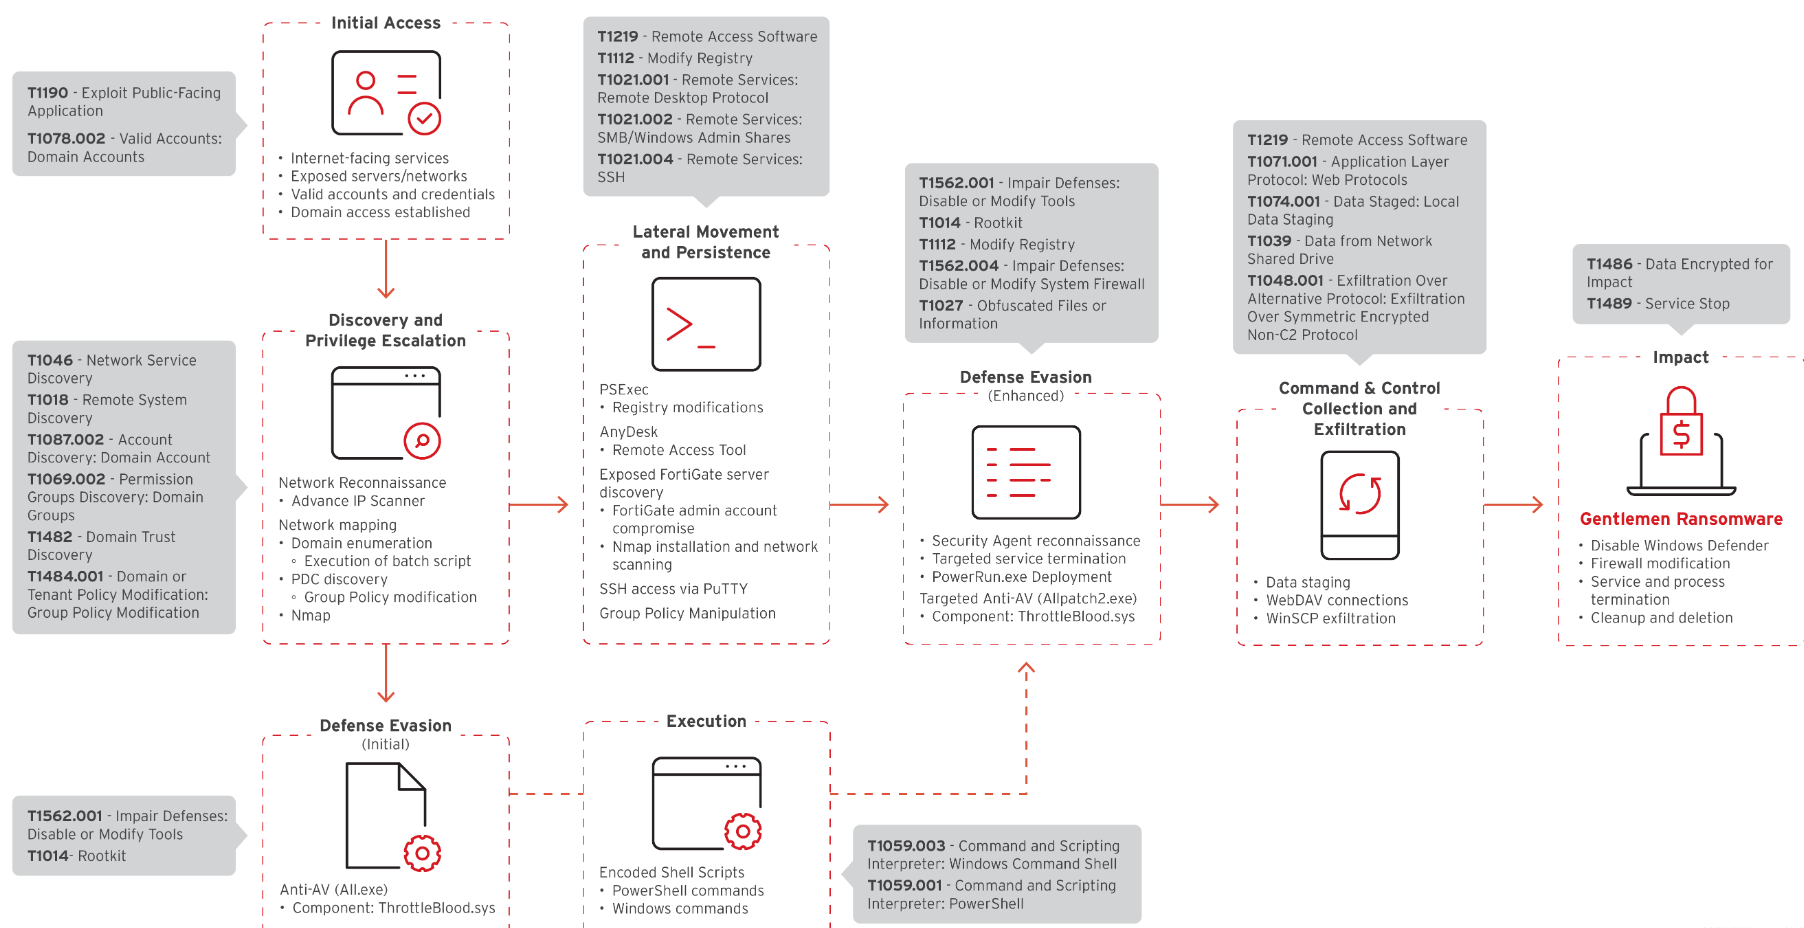

### <span style="color:teal">3 - **Hypothesis**</span> 

### <span style="color:orange">Defense Evasion (TA0005):</span>


Hunt Hypothesis: Gentlemen Ransomware — Defense Evasion — ***Divided in sub-hypothesis***<br>
Tactic: Defense Evasion (TA0005)<br>
Confidence: High<br>
ATT&CK Coverage: T1562.001, T1562.002, T1070.001, T1070.004, T1112, T1211, T1548, T1059.001, T1021.002, T1490<br>

| Hypothesis naming convention |               |
|:---          |:------------------------- |
| H            | Hypothesis                |
| GR           | Gentlemen Ransomware      |
| DE           | Defense Evasion (TA0005)  |
| 0#           | Sequential number         |

<span style="color:orange">H-GR-DE-01:</span>

The adversary is deploying All.exe alongside a vulnerable signed kernel driver
(ThrottleBlood.sys) to perform BYOVD (Bring Your Own Vulnerable Driver) attacks
(T1211), enabling kernel-level manipulation to terminate protected security
processes including AV and EDR solutions (T1562.001).

<span style="color:orange">H-GR-DE-02:</span>

PowerRun.exe is used to execute high-privilege operations targeting security
services (T1548), while Allpatch2.exe neutralizes security agent components by
terminating relevant processes (T1562.001).

<span style="color:orange">H-GR-DE-03:</span>

The adversary disables Microsoft Defender and adds exclusions via PowerShell
(T1059.001 / T1562.001):
  - Set-MpPreference -DisableRealtimeMonitoring $true -Force
  - Add-MpPreference -ExclusionProcess <malware_name> -Force
  - Add-MpPreference -ExclusionPath C:\ -Force

<span style="color:orange">H-GR-DE-04:</span>

Forensic artifacts are destroyed including Windows Event Logs, prefetch files,
RDP logs, and PowerShell history (T1070.001, T1070.004). Running Windows
services are stopped to inhibit recovery (T1490).

<span style="color:orange">H-GR-DE-05:</span>

Registry keys under HKLM\SYSTEM\CurrentControlSet\Control\WMI (AutoLogger,
GlobalLogger) are modified to disable AV telemetry (e.g., BitDefender) (T1112). 

AutoLogger and GlobalLogger are part of Windows' built-in Event Tracing for Windows (ETW) infrastructure.
They control system-wide logging sessions for various purposes, including OS diagnostics, performance monitoring, and telemetry.
Many software products, including operating system components, third-party security solutions, and EDR tools, may use or interact with these keys to enable or disable telemetry.

<span style="color:orange">H-GR-DE-06:</span>

Group Policy is manipulated to disable EDR solutions, enforced via
gpupdate /force (T1562.001).

<span style="color:orange">H-GR-DE-07:</span>

The adversary uses nxc (NetExec), a post-exploitation framework, over the SMB protocol to remotely disable Microsoft Defender on target hosts and add C:\ and the malware process name to Defender's exclusion list — effectively propagating defense evasion laterally across the environment without requiring interactive access to each endpoint.

nxc smb <target> -u <user> -p <pass> -M defender --action disable

nxc smb <target> -u <user> -p <pass> -M defender --add-exclusion-path C:\

nxc smb <target> -u <user> -p <pass> -M defender --add-exclusion-process <malware_name>

### <span style="color:teal">4 - **Data availability**</span>


### Data Availability Matrix

| Hunting Query | ATT&CK | Table | Retention |
|:---|:---:|:---|:---:|
| [H-GR-DE-01](ca://s?q=Explain_H-GR-DE-01) | T1211, T1562.001 | DeviceProcessEvents, DeviceFileEvents, DeviceImageLoadEvents | 30 days |
| [H-GR-DE-02](ca://s?q=Explain_H-GR-DE-02) | T1548, T1562.001 | DeviceFileEvents, DeviceProcessEvents | 30 days |
| [H-GR-DE-03](ca://s?q=Explain_H-GR-DE-03) | T1059.001, T1562.001 | DeviceProcessEvents | 30 days |
| [H-GR-DE-04](ca://s?q=Explain_H-GR-DE-04) | T1070.001, T1070.004, T1490 | DeviceProcessEvents | 30 days |
| [H-GR-DE-05](ca://s?q=Explain_H-GR-DE-05) | T1112 | DeviceRegistryEvents | 30 days |
| [H-GR-DE-06](ca://s?q=Explain_H-GR-DE-06) | T1484.001, T1562.001 | DeviceProcessEvents, DeviceFileEvents | 30 days |
| [H-GR-DE-07](ca://s?q=Explain_H-GR-DE-07) | T1021.002, T1562.001 | DeviceProcessEvents, DeviceNetworkEvents | 30 days |


### <span style="color:teal">5 - **Hunts**</span>

Hunting Query 1<br>
<span style="color:orange">H-GR-DE-01: BYOVD Attack with Vulnerable Driver</span><br>
<br>
**Purpose:** Detect BYOVD (Bring Your Own Vulnerable Driver) attacks using ThrottleBlood.sys with All.exe to kill protected processes<br>
**Confidence:** Extremely High - This combination is rarely seen outside ransomware<br>
**False Positive Rate:** Negligible - ThrottleBlood.sys abuse is a strong indicator<br>
**Tuning Tip:** Correlate All.exe + ThrottleBlood.sys appearance with process terminations to confirm attack<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** All.exe + ThrottleBlood.sys appearing in process creation and file events; SYSTEM-level process terminations without explicit user action.

In [ ]:
// ---------------------------------------------------------------
// Hunting: "Gentlemen" Ransomware - BYOVD via ThrottleBlood.sys
// MITRE: T1211 (Exploitation for Defense Evasion), T1562.001
// ---------------------------------------------------------------
union
(
    DeviceProcessEvents // --- Signal 1: Process Execution of All.exe ---
    | where FileName =~ "All.exe"
        or InitiatingProcessFileName =~ "All.exe"
        or InitiatingProcessParentFileName =~ "All.exe"
    | extend SignalType = "ProcessExecution"
),
(
    DeviceFileEvents    // --- Signal 2: File Creation of suspicious files (BYOVD drop) ---
    | where FileName has_any ("All.exe", "ThrottleBlood.sys")
    | extend SignalType = "FileDrop"
),
(
    DeviceImageLoadEvents   // --- Signal 3: Vulnerable driver load ---
    | where FileName =~ "ThrottleBlood.sys"
        or InitiatingProcessFileName =~ "All.exe"
    | extend SignalType = "VulnerableDriverLoad"
)
| project           // --- Union all signals and project relevant fields ---
    TimeGenerated,
    DeviceName,
    SignalType,
    ActionType,
    FileName,
    FolderPath,
    SHA256,
    FileSize,
    ProcessCommandLine,
    InitiatingProcessFileName,
    InitiatingProcessID,
    InitiatingProcessCommandLine,
    InitiatingProcessParentFileName
| sort by TimeGenerated desc

Hunting Query 2<br>
<span style="color:orange">H-GR-DE-02: Privilege Abuse & Defense Evasion Tools</span><br>
<br>
**Purpose:** Detect PowerRun.exe and Allpatch2.exe being deployed and executed<br>
**Confidence:** High - These tools are specifically designed for privilege escalation and security disabling<br>
**False Positive Rate:** Very Low - Both tools are rarely seen in legitimate environments<br>
**Tuning Tip:** Look for both file drops AND execution. If you see only the drop, the attacker may have been interrupted<br>
**Expected Pattern:** FileDrop followed by ProcessExecution within minutes<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** PowerRun or Allpatch2 execution chains; suspicious parent-child relationships with security service processes.

In [ ]:
// ---------------------------------------------------------------
// Hunting: Privilege Abuse & Defense Evasion
// PowerRun.exe  → T1548  (Abuse Elevation Control Mechanism)
// Allpatch2.exe → T1562.001 (Impair Defenses: Disable/Stop Security Tools)
// ---------------------------------------------------------------
union
(
    DeviceFileEvents    // --- Signal 1: File drop of either binary to disk ---
    | where FileName in~ ("PowerRun.exe", "Allpatch2.exe")
    | extend SignalType = "FileDrop"
),
(
   DeviceProcessEvents  // --- Signal 2: Direct execution, child or grandchild process activity ---
    | where FileName in~ ("PowerRun.exe", "Allpatch2.exe")
        or InitiatingProcessFileName in~ ("PowerRun.exe", "Allpatch2.exe")
        or InitiatingProcessParentFileName in~ ("PowerRun.exe", "Allpatch2.exe")
    | extend SignalType = "ProcessExecution"
)
| project
    TimeGenerated,
    DeviceName,
    SignalType,
    ActionType,
    FileName,
    FolderPath,
    SHA256,
    FileSize,
    ProcessCommandLine,
    InitiatingProcessFileName,
    InitiatingProcessId,
    InitiatingProcessCommandLine,
    InitiatingProcessParentFileName
| sort by TimeGenerated desc


Hunting Query 3<br>
<span style="color:orange">H-GR-DE-03: Defender Tampering via PowerShell</span><br>
<br>
**Purpose:** Detect real-time disabling of Microsoft Defender protections via PowerShell cmdlets<br>
**Confidence:** Very High - `Set-MpPreference` with `DisableRealtimeMonitoring` is rare in legitimate environments<br>
**False Positive Rate:** Low if PowerShell logging is enabled (rare in legitimate patches)<br>
**Tuning Tip:** Add your approved patching accounts to the exclusion filter if you have automated Defender management<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** PowerShell command-line arguments with MpPreference keywords; Registry writes to Defender policy keys.


In [ ]:
// ---------------------------------------------------------------
// Hunting: Defender Tampering via PowerShell
// T1059.001 - Command and Scripting Interpreter: PowerShell
// T1562.001 - Impair Defenses: Disable or Modify Tools
// ---------------------------------------------------------------
DeviceProcessEvents
| where FileName in~ ("powershell.exe", "pwsh.exe")
| where ProcessCommandLine has_any (
    "Set-MpPreference",
    "Add-MpPreference",
    "DisableRealtimeMonitoring",
    "ExclusionProcess",
    "ExclusionPath",
    "DisableIOAVProtection",
    "DisableBehaviorMonitoring"
)
| extend TacticTag = case(      // extend adds a new calculated column to each row in your results. It gives instant triage context in the results without needing to read the raw command line.
    ProcessCommandLine has "DisableRealtimeMonitoring", "T1562.001 - Disable Realtime Monitoring",
    ProcessCommandLine has "ExclusionProcess",          "T1562.001 - Add Exclusion: Process",
    ProcessCommandLine has "ExclusionPath",             "T1562.001 - Add Exclusion: Path",
    "T1562.001 - Defender Tampering"
)
| summarize Count = count() by TacticTag, DeviceName
| sort by Count desc

Hunting Query 4<br>
<span style="color:orange">H-GR-DE-04:</span>
<span style="color:orange">H-GR-DE-04: Forensic Artifact Destruction & Service Inhibition</span><br>
<br>
**Purpose:** Catch destructive actions that eliminate forensic evidence and disable recovery<br>
**Confidence:** Very High for `wevtutil cl` or `vssadmin delete` combined<br>
**False Positive Rate:** **MEDIUM** - maintenance scripts and antivirus tools may clear logs legitimately<br>
**Tuning Tips:**
  - Exclude known backup software by ParentProcess or AccountName
  - Exclude scheduled maintenance tasks running as SYSTEM
  - Look for **combinations** of signals (log clear + service stop) rather than isolated events
  - Flag rapid sequences of 3+ signals within 5 minutes as suspicious<br>

**Data Source:** Microsoft Defender - KQL query (use with caution due to potential FPs)<br>
**Expected Telemetry:** `wevtutil cl`, `Clear-EventLog`, `vssadmin`, service stop commands in rapid succession.


In [ ]:
// ---------------------------------------------------------------
// Hunting: Forensic Artifact Destruction & Service Inhibition
// T1070.001 - Indicator Removal: Clear Windows Event Logs
// T1070.004 - Indicator Removal: File Deletion
// T1490     - Inhibit System Recovery
// ---------------------------------------------------------------
union
(
    DeviceProcessEvents     // --- Signal 1: Event Log Clearing ---
    | where FileName in~ ("wevtutil.exe", "powershell.exe", "pwsh.exe", "cmd.exe")
    | where ProcessCommandLine has_any (
        "wevtutil cl",
        "wevtutil.exe cl",
        "Clear-EventLog",
        "Remove-EventLog",
        "TerminalServices",
        "Microsoft-Windows-PowerShell",
        "Security",
        "System",
        "Application"
    )
    | where ProcessCommandLine has_any ("cl ", "clear-log", "Clear-EventLog")
    | extend SignalType = "EventLogClearing"
    | extend TacticTag = "T1070.001 - Clear Windows Event Logs"
),
(
    DeviceProcessEvents     // --- Signal 2: Prefetch & PowerShell History Deletion ---
    | where FileName in~ ("powershell.exe", "pwsh.exe", "cmd.exe")
    | where ProcessCommandLine has_any (
        "ConsoleHost_history",
        "PSReadLine",
        "Prefetch",
        ".pf",
        "C:\\Windows\\Prefetch",
        "del /f",
        "del /q",
        "Remove-Item",
        "rm -Force",
        "rmdir"
    )
    | extend SignalType = "FileArtifactDeletion"
    | extend TacticTag = "T1070.004 - File Deletion"
),
(
    DeviceProcessEvents     // --- Signal 3: RDP Log Clearing ---
    | where FileName in~ ("wevtutil.exe", "powershell.exe", "pwsh.exe", "cmd.exe")
    | where ProcessCommandLine has_any (
        "TerminalServices",
        "TerminalServices-LocalSessionManager",
        "TerminalServices-RemoteConnectionManager",
        "Microsoft-Windows-TerminalServices",
        "RDPClient"
    )
    | extend SignalType = "RDPLogClearing"
    | extend TacticTag = "T1070.001 - Clear RDP Logs"
),
(
    DeviceProcessEvents     // --- Signal 4: Service Stopping to Inhibit Recovery ---
    | where FileName in~ ("net.exe", "net1.exe", "sc.exe", "powershell.exe", "pwsh.exe", "cmd.exe")
    | where ProcessCommandLine has_any (
        "net stop",
        "sc stop",
        "sc delete",
        "Stop-Service",
        "vss",
        "VSS",
        "wbengine",
        "SDRSVC",
        "swprv",
        "backup",
        "MSSQLServer",
        "SQLWriter",
        "WinDefend",
        "Sense",
        "MsMpEng"
    )
    | extend SignalType = "ServiceInhibition"
    | extend TacticTag = "T1490 - Inhibit System Recovery"
)
| project
    TimeGenerated,
    DeviceName,
    SignalType,
    TacticTag,
    AccountName,
    FileName,
    ProcessCommandLine,
    InitiatingProcessFileName,
    InitiatingProcessCommandLine,
    InitiatingProcessParentFileName,
    FolderPath,
    SHA256
| sort by TimeGenerated desc

In [ ]:
// ---------------------------------------------------------------
// OPTIONAL TRIAGE VIEW: summarize by signal type and device
// Use this AFTER the main query above to get a quick count.
// WARNING: generates more false positives — use as a dashboard view only
// ---------------------------------------------------------------
//Append this to get a quick triage view across devices:
| summarize Count = count() by TacticTag, SignalType, DeviceName
| sort by Count desc                                                            // this one can generate lots of false positives depending on the environment

Hunting Query 5<br>
<span style="color:orange">H-GR-DE-05: Registry Modification to Disable AV Telemetry</span><br>
<br>
**Purpose:** Detect modifications to ETW logging infrastructure that disables AV/EDR telemetry<br>
**Confidence:** Very High - AutoLogger/GlobalLogger registry tampering is a sophisticated adversary behavior<br>
**False Positive Rate:** Very Low - These keys are rarely touched by legitimate software<br>
**Tuning Tip:** This is often paired with other evasion tactics. Look for correlations with other signals<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** Registry modifications to `HKLM\SYSTEM\CurrentControlSet\Control\WMI\AutoLogger` or `GlobalLogger` keys; often paired with T1112 modifications.

In [ ]:
// ---------------------------------------------------------------
// Hunting: Registry Modification to Disable AV Telemetry
// T1112 - Modify Registry
// Target: HKLM\SYSTEM\CurrentControlSet\Control\WMI\AutoLogger
//         HKLM\SYSTEM\CurrentControlSet\Control\WMI\GlobalLogger
// Effect: Disables ETW-based AV/EDR telemetry (e.g. BitDefender)
// ---------------------------------------------------------------

DeviceRegistryEvents
| where ActionType in (
    "RegistryValueSet",
    "RegistryKeyCreated",
    "RegistryKeyDeleted",
    "RegistryValueDeleted"
)
| where RegistryKey has_all (
    "SYSTEM\\CurrentControlSet\\Control\\WMI"
)
| where RegistryKey has_any (
    "AutoLogger",
    "GlobalLogger"
)
| extend TacticTag = case(
    RegistryKey has "AutoLogger",   "T1112 - Modify AutoLogger (Disable ETW Telemetry)",
    RegistryKey has "GlobalLogger", "T1112 - Modify GlobalLogger (Disable ETW Telemetry)",
    "T1112 - WMI Registry Tampering"
)
| project
    TimeGenerated,
    DeviceName,
    TacticTag,
    ActionType,
    RegistryKey,
    RegistryValueName,
    RegistryValueData,
    InitiatingProcessAccountName,
    InitiatingProcessAccountUpn,
    InitiatingProcessFileName,
    InitiatingProcessCommandLine,
    InitiatingProcessParentFileName,
    InitiatingProcessFolderPath,
    InitiatingProcessParentCreationTime
| sort by TimeGenerated desc

Hunting Query 6<br>
<span style="color:orange">H-GR-DE-06: Group Policy Manipulation for EDR Bypass</span><br>
<br>
**Purpose:** Detect modifications to Group Policy that disable EDR/AV solutions domain-wide<br>
**Confidence:** Very High - Direct GPO edits or `gpupdate /force` with policy changes are suspicious<br>
**False Positive Rate:** Low - Legitimate Group Policy changes should be planned and documented<br>
**Tuning Tip:** Whitelist your organization's approved policy management accounts and admin groups<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** `gpupdate /force` commands; `gpmc.msc` or `gpedit.msc` process creation; policy registry modifications under `HKLM\Software\Policies\Microsoft`.

In [ ]:
// ---------------------------------------------------------------
// Hunting: Group Policy Manipulation for EDR Bypass
// T1484.001 - Modify Domain Policy (GPO abuse)
// T1562.001 - Impair Defenses via policy
// ---------------------------------------------------------------
union
(
    DeviceProcessEvents     // --- Signal 1: GPO Editor Execution ---
    | where FileName in~ ("gpme.msc", "gpedit.msc", "gpmc.msc", "mmc.exe")
    | where ProcessCommandLine has_any ("gpme.msc", "gpedit.msc", "gpmc.msc")
        or (FileName =~ "mmc.exe" and ProcessCommandLine has_any ("gp", "gpme", "gpedit"))
    | extend SignalType = "GPO_Tool_Execution"
),
(
    DeviceProcessEvents     // --- Signal 2: gpupdate /force after suspicious activity ---
    | where FileName in~ ("gpupdate.exe", "powershell.exe", "pwsh.exe", "cmd.exe")
    | where ProcessCommandLine has "gpupdate" and ProcessCommandLine has "force"
    | extend SignalType = "GPUpdate_Force"
),
(
    DeviceRegistryEvents   // --- Signal 3: Registry writes to Group Policy paths ---
    | where RegistryKey startswith "HKLM\\Software\\Policies\\"
    | where RegistryKey has_any (
        "Microsoft\\Windows Defender",
        "Windows NT\\CurrentVersion\\Winlogon",
        "Services\\WinDefend",
        "Services\\Sense",
        "Services\\MsMpEng"
    )
    | where ActionType in ("RegistryValueSet", "RegistryKeyCreated")
    | extend SignalType = "PolicyRegistry_Write"
)
| project
    TimeGenerated,
    DeviceName,
    SignalType,
    FileName,
    ProcessCommandLine,
    AccountName = InitiatingProcessAccountName,
    RegistryKey,
    RegistryValueName,
    FolderPath = InitiatingProcessFolderPath
| sort by TimeGenerated desc

Hunting Query 7<br>
<span style="color:orange">H-GR-DE-07: Lateral Defender Disabling via NetExec/SMB</span><br>
<br>
**Purpose:** Detect NetExec/SMB use of the Defender module to disable Defender and add exclusions across multiple hosts<br>
**Confidence:** Very High - This is a specific lateral defense-evasion pattern tied to NetExec and the Defender module<br>
**False Positive Rate:** Very Low - NetExec Defender module usage is uncommon outside post-exploitation<br>
**Tuning Tip:** Adjust the `summarize AffectedHosts > 2` threshold based on your environment<br>
**Expected Findings:** A small number of hosts showing `nxc`/`netexec` execution with `--action disable`, `--add-exclusion-path`, or `--add-exclusion-process` in the same time window<br>
**Data Source:** Microsoft Defender - KQL query<br>
**Expected Telemetry:** NetExec/SMB execution (`nxc.exe`/`netexec.exe`) with Defender module arguments; PowerShell child processes that add `MpPreference` exclusions on multiple hosts.

In [ ]:
// ---------------------------------------------------------------
// Hunting: Lateral Defender Disabling via NetExec/SMB
// T1021.002 - SMB/Windows Admin Shares
// T1059.001 - Command and Scripting Interpreter: PowerShell
// T1562.001 - Impair Defenses: Disable or Modify Tools
// ---------------------------------------------------------------
let DefenderNxcSignals =
    DeviceProcessEvents
    | where FileName in~ ("nxc.exe", "netexec.exe", "nxc", "netexec")
    | where ProcessCommandLine has_any ("smb", "defender")
    | where ProcessCommandLine has_any ("--action disable", "--add-exclusion-path", "--add-exclusion-process")
    | extend Command = case(
        ProcessCommandLine has "--action disable", "Disable Defender",
        ProcessCommandLine has "--add-exclusion-path" and ProcessCommandLine has_any ("C:\\", "c:\\"), "Add Path Exclusion (C:\\)",
        ProcessCommandLine has "--add-exclusion-path", "Add Path Exclusion",
        ProcessCommandLine has "--add-exclusion-process", "Add Process Exclusion",
        "NetExec Defender Module"
    )
    | project TimeGenerated, DeviceName, SourceProcess = FileName, Command, ProcessCommandLine, AccountName = InitiatingProcessAccountName;
let RemoteDefenderChanges =
    DeviceProcessEvents
    | where InitiatingProcessFileName in~ ("nxc.exe", "netexec.exe", "cme.exe")
    | where ProcessCommandLine has_any ("Add-MpPreference", "Set-MpPreference", "ExclusionPath", "ExclusionProcess", "DisableRealtime")
    | where ProcessCommandLine has_any ("DisableRealtime", "ExclusionProcess") or (ProcessCommandLine has_any ("ExclusionPath") and ProcessCommandLine has_any ("C:\\", "c:\\"))
    | extend Command = case(
        ProcessCommandLine has "ExclusionPath" and ProcessCommandLine has_any ("C:\\", "c:\\"), "Add Path Exclusion (C:\\)",
        ProcessCommandLine has "ExclusionProcess", "Add Process Exclusion",
        ProcessCommandLine has "DisableRealtime", "Disable Realtime Monitoring",
        "Defender Config Change"
    )
    | project TimeGenerated, DeviceName, SourceProcess = InitiatingProcessFileName, Command, ProcessCommandLine, AccountName = InitiatingProcessAccountName;
union DefenderNxcSignals, RemoteDefenderChanges
| summarize
    AffectedHosts = dcount(DeviceName),
    FirstSeen = min(TimeGenerated),
    LastSeen = max(TimeGenerated),
    Commands = make_set(Command)
    by SourceProcess, ProcessCommandLine, AccountName
| where AffectedHosts > 2  // Threshold: alert if this activity appears on 3+ hosts
| sort by AffectedHosts desc

### <span style="color:teal">6 — Analyst Disposition Framework</span>
After running each hunt query, document your findings using this structure:

| Field | Value |
|---|---|
| Hunt ID | H-GR-DE-0# |
| Hypothesis | *(copy from Section 3)* |
| ATT&CK Technique | T1xxx.xxx |
| Data Source | DeviceProcessEvents / DeviceRegistryEvents / etc. |
| Time Window Analyzed | Last 30 days |
| Total Raw Results | # rows returned |
| After Tuning / Allowlisting | # rows remaining |
| Disposition | ✅ Clean / ⚠️ Suspicious / 🔴 Confirmed Malicious |
| Escalated to IR | Yes / No |
| Detection Opportunity | Build Sentinel analytic rule / Alert / No action |
| Notes | *(anything that stood out, allowlisted accounts, tuning applied)* |

### Escalation Triggers

Escalate **immediately** to Incident Response if you observe:

- `ThrottleBlood.sys` loaded by any process → BYOVD attack in progress (H-GR-DE-01)
- `All.exe` + `ThrottleBlood.sys` appearing on the same host within 10 minutes
- `PowerRun.exe` or `Allpatch2.exe` executed from a non-standard path
- `Set-MpPreference -DisableRealtimeMonitoring` combined with `wevtutil cl`
- Same `Add-MpPreference ExclusionPath C:\` command appearing on 3+ hosts within 30 minutes
- AutoLogger or GlobalLogger registry key modification by a non-SYSTEM account

### Detection Engineering Handoff

Confirmed hunt findings should be converted to **persistent Sentinel Analytic Rules**:

1. Open Microsoft Sentinel → **Analytics → Create → Scheduled query rule**
2. Paste the confirmed KQL query
3. Set alert threshold, frequency, and lookback window
4. Map to the MITRE ATT&CK technique
5. Tag with `GentlemenRansomware` and the hunt ID (e.g., `H-GR-DE-01`)

---

*Author: Marcio Mota | CISSP · GCFA · eCTHPv2 | Threat Hunter*  
*Sources: [Huntress](https://www.huntress.com/blog/the-gentlemen-ransomware-defense-evasion-ttps) · [Trend Micro](https://www.trendmicro.com/en_us/research/25/i/unmasking-the-gentlemen-ransomware.html) · [Microsoft Security Blog](https://www.microsoft.com/en-us/security/blog/2026/05/28/the-gentlemen-ransomware-dissecting-a-self-propagating-go-encryptor/) · [Group-IB](https://www.group-ib.com/blog/hastalamuerte-gentlemen-raas-ttps/)*  
*GitHub: [github.com/marciomota](https://github.com) · Medium: [@marcio22silveira](https://medium.com/@marcio22silveira)*


### Based on ***[From CTI report to Hunt Hypothesis](https://medium.com/@marcio22silveira/from-cti-report-to-hunt-hypothesis-a-practitioners-guide-46e2acfdd7e4)***. 

1 - Take one recent threat report relevant to your sector, extract three behaviors;

<span style="color:yellow">2 - Map them to ATT&CK;</span>   
                               
<span style="color:yellow">3 - Write the hypotheses;</span> 

4 - Check your data availability;

5 - Run the hunt.

6 - Repeat that twenty times and you’ll have a methodology that scales.

https://medium.com/@marcio22silveira/from-cti-report-to-hunt-hypothesis-a-practitioners-guide-46e2acfdd7e4